# Notebook 2.4e: Path-Level Marginal Analysis

**Purpose:** Quantify the marginal contribution of each origin-destination path to decongestion under different subsidy scenarios.

**Key Concepts:**
- **Existing paths**: Origin-destination pairs with observed student flow
- **Hypothetical paths**: Pairs generated as potential options but no observed flow
- **Marginal contribution**: Additional decongestion from increasing subsidy

**Policy Question:**
> "What is the marginal contribution of hypothetical paths to decongestion?"

**Related Documentation:** `references/documentation/dcm_informed_policy_simulation.md`

---
# 0. Setup

In [145]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

pd.set_option("display.max_columns", None)

PROJECT_DIR = Path.cwd().parent
OUTPUT_DIR = PROJECT_DIR / "output"

print(f"Project directory: {PROJECT_DIR}")

Project directory: /workspace/project_paaral


---
# 1. Load Data

We need three datasets:
1. **Candidate Beneficiary Pool** — All origin-destination pairs with mu values
2. **Observed Student Flow** — To identify existing vs hypothetical paths
3. **Flow to Congested** — To link origins to congested public schools

In [2]:
# Candidate beneficiary pool (311K pairs with mu values)
cbp = pd.read_parquet(OUTPUT_DIR / "full_candidate_beneficiary_pool_without_probdist_0207_model4.parquet")
print(f"Candidate beneficiary pool: {cbp.shape[0]:,} pairs")

Candidate beneficiary pool: 325,395 pairs


In [3]:
display(cbp.head(3))

,origin_school_id,destination_school_id,origin_sector,origin_region,destination_sector,tuition_fees_k,destination_tuition_fees,distance_meters,distance_km,net_cost,net_cost_k,esc_rating,log_distance,log_tuition,log_net_cost_k,destination_jhs_enrollment,esc_amount,esc_amount_k,candidate_pool,log_origin_lgu_income,log_destination_lgu_income,scaled_origin_income,scaled_dest_income,destination_region,net_cost_baseline_0_subsidy,mu_baseline_0_subsidy,net_cost_current_subsidy,mu_current_subsidy,net_cost_minus_1k_net_cost,mu_minus_1k_net_cost,net_cost_minus_2k_net_cost,mu_minus_2k_net_cost,net_cost_minus_3k_net_cost,mu_minus_3k_net_cost,net_cost_minus_4k_net_cost,mu_minus_4k_net_cost,net_cost_minus_5k_net_cost,mu_minus_5k_net_cost,net_cost_minus_6k_net_cost,mu_minus_6k_net_cost,net_cost_minus_7k_net_cost,mu_minus_7k_net_cost,net_cost_minus_8k_net_cost,mu_minus_8k_net_cost,net_cost_minus_9k_net_cost,mu_minus_9k_net_cost,net_cost_minus_10k_net_cost,mu_minus_10k_net_cost,net_cost_minus_11k_net_cost,mu_minus_11k_net_cost,net_cost_minus_12k_net_cost,mu_minus_12k_net_cost,net_cost_minus_13k_net_cost,mu_minus_13k_net_cost,net_cost_minus_14k_net_cost,mu_minus_14k_net_cost,net_cost_minus_15k_net_cost,mu_minus_15k_net_cost,net_cost_minus_16k_net_cost,mu_minus_16k_net_cost,net_cost_minus_17k_net_cost,mu_minus_17k_net_cost,net_cost_minus_18k_net_cost,mu_minus_18k_net_cost,net_cost_minus_19k_net_cost,mu_minus_19k_net_cost,net_cost_minus_20k_net_cost,mu_minus_20k_net_cost
0,104408,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,215159.4,215.1594,9525.0,9.525,0.0,5.376016,2.971696,2.353753,949.0,9000.0,9.0,71.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.528323,9.525,0.565609,8.525,0.571876,7.525,0.578919,6.525,0.586946,5.525,0.596255,4.525,0.607303,3.525,0.620833,2.525,0.638182,1.525,0.662118,0.525,0.700009,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381
1,104412,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,216821.4,216.8214,9525.0,9.525,0.0,5.383675,2.971696,2.353753,949.0,9000.0,9.0,83.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.526507,9.525,0.563665,8.525,0.569910,7.525,0.576929,6.525,0.584928,5.525,0.594205,4.525,0.605215,3.525,0.618699,2.525,0.635989,1.525,0.659842,0.525,0.697603,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860
2,104457,401070,Public,Region III (Central Luzon),Private,13.350,13350.0,95035.2,95.0352,4350.0,4.350,0.0,4.564715,2.663750,1.677097,1794.0,9000.0,9.0,85.0,16.759161,19.555293,-1.986060,-0.639071,Region III (Central Luzon),13.350,0.827759,4.350,0.922982,3.350,0.944302,2.350,0.971920,1.350,1.010703,0.350,1.074462,0.000,1.110643,0.000,1.110643,0.000,1.110643,0.000,1.110643,0.000,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643,0.0,1.110643


In [4]:
# Check for NaNs, if any
display(cbp.isna().sum().sort_values(ascending=False))

origin_school_id               0
mu_minus_8k_net_cost           0
mu_minus_11k_net_cost          0
net_cost_minus_11k_net_cost    0
mu_minus_10k_net_cost          0
                              ..
net_cost_minus_1k_net_cost     0
mu_minus_1k_net_cost           0
net_cost_minus_2k_net_cost     0
mu_minus_2k_net_cost           0
mu_minus_20k_net_cost          0
Length: 68, dtype: int64

In [5]:
# Observed student flow (existing paths)
student_flow = pd.read_parquet(OUTPUT_DIR / "grade_7_student_flow_table_sy2324.parquet")
print(f"Observed student flow: {student_flow.shape[0]:,} pairs")
print(f"Columns: {student_flow.columns.tolist()}")

Observed student flow: 288,328 pairs
Columns: ['school_id_origin', 'school_id_destination', 'count_non_beneficiary', 'count_esc_beneficiary']


In [91]:
display(student_flow.head(2))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN
1,100000,300388,25.0,NaN


In [6]:
# Flow to congested public schools
flow_to_congested = pd.read_parquet(OUTPUT_DIR / "analysis_payload" / "flow_to_congested.parquet")
print(f"Flow to congested: {flow_to_congested.shape[0]:,} rows")
print(f"Columns: {flow_to_congested.columns.tolist()}")

Flow to congested: 36,164 rows
Columns: ['school_id_origin', 'school_id_destination', 'count_non_beneficiary', 'count_esc_beneficiary', 'count_aisle_learner_jhs', 'seat_utilization_jhs', 'enrollment_jhs', 'seat_count']


In [7]:
# Load ESC availability from 2.4c outputs
fpath = str(OUTPUT_DIR / "analysis_payload" / "esc_available.parquet")
esc_available = pd.read_parquet(fpath)
esc_available.rename(
    columns={'school_id':'destination_school_id'},
    inplace=True
)

mask = esc_available['available_slots'] < 0
esc_available.loc[mask, 'available_slots'] = 0  # Transform to 0 negative slots

# System slots or sum of available slots of ESC in NCR, R4A & R3
system_slots = esc_available['available_slots'].sum()

print(f"ESC available shape: {esc_available.shape}")
display(esc_available.head(2))
print(f"\nCount of available slots in the system: {system_slots:,.0f}")

ESC available shape: (1447, 3)


,destination_school_id,slots_total,available_slots
0,418013,38,6
1,419005,50,30



Count of available slots in the system: 26,608


---
# 2. Create `is_hypothetical` Flag

A path is **existing** if it appears in the observed student flow data (any flow, ESC or non-beneficiary).

A path is **hypothetical** if it was generated but has no observed flow.

In [8]:
# Ensure consistent types for merging
cbp['origin_school_id'] = cbp['origin_school_id'].astype(str)
cbp['destination_school_id'] = cbp['destination_school_id'].astype(str)

student_flow['school_id_origin'] = student_flow['school_id_origin'].astype(str)
student_flow['school_id_destination'] = student_flow['school_id_destination'].astype(str)

In [9]:
# Create set of existing (origin, destination) pairs
existing_pairs = set(
    zip(student_flow['school_id_origin'], student_flow['school_id_destination'])
)
print(f"Existing pairs in flow data: {len(existing_pairs):,}")

Existing pairs in flow data: 288,328


In [10]:
# Flag hypothetical paths
cbp['is_hypothetical'] = ~cbp.apply(
    lambda row: (row['origin_school_id'], row['destination_school_id']) in existing_pairs,
    axis=1
)

print(f"\nPath classification:")
print(cbp['is_hypothetical'].value_counts().rename({True: 'Hypothetical', False: 'Existing'}))


Path classification:
is_hypothetical
Hypothetical    234972
Existing         90423
Name: count, dtype: int64


## 2.1. Inspect

In [11]:
# Let's get the sums of `mu`s to detect if the predicted flow is
# constrained or not
od_cols = ['origin_school_id','destination_school_id']
mu_cols = [col for col in cbp.columns if re.search(r'mu_minus', col)]
ess_cols = od_cols + mu_cols

df_mu = cbp[ess_cols].copy()
df_mu_sums = df_mu.loc[:,"mu_minus_1k_net_cost":].sum()

In [12]:
# The display shows that the `mu`s are unconstrained
display(df_mu_sums.to_frame().style.format("{:,.0f}"))

,0
mu_minus_1k_net_cost,"870,000"
mu_minus_2k_net_cost,"876,162"
mu_minus_3k_net_cost,"882,732"
mu_minus_4k_net_cost,"889,342"
mu_minus_5k_net_cost,"896,393"
mu_minus_6k_net_cost,"904,288"
mu_minus_7k_net_cost,"913,091"
mu_minus_8k_net_cost,"921,387"
mu_minus_9k_net_cost,"929,894"
mu_minus_10k_net_cost,"938,445"


Notes:
* The ESC schools in our NCR, R4A, and R3 system only has 26,608 unutilized slots (or slots that are remaining after accepting beneficiaries in SY 23-24). We view these slots as a mechanism to divert non-beneficiaries flowing to congested public JHS
* existing_mu + hypo_mu = all_mu
* Hypothesis: all_mu > system_unutilized_slots
    * randomly sample and compute cumulative_mu from existing + hypo mu until <= system_unutilized_slots
    * iterate 1,000 times

---
# 3. Compute Proportional Weights for Congested Schools

An origin school may feed students into multiple congested public schools. We compute the **proportional weight** based on observed flow volume.

$$
\text{weight}_{\text{origin} \rightarrow \text{congested}_C} = \frac{\text{flow to } C}{\text{total flow to all congested schools}}
$$

In [13]:
# Ensure consistent types
flow_to_congested['school_id_origin'] = flow_to_congested['school_id_origin'].astype(str)
flow_to_congested['school_id_destination'] = flow_to_congested['school_id_destination'].astype(str)

# Check columns for flow count
print("Columns in flow_to_congested:")
print(flow_to_congested.columns.tolist())

Columns in flow_to_congested:
['school_id_origin', 'school_id_destination', 'count_non_beneficiary', 'count_esc_beneficiary', 'count_aisle_learner_jhs', 'seat_utilization_jhs', 'enrollment_jhs', 'seat_count']


In [14]:
# Inspect a few rows to understand the data
display(flow_to_congested.head())

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary,count_aisle_learner_jhs,seat_utilization_jhs,enrollment_jhs,seat_count
0,101701,301194,1.0,NaN,4523.0,2.847631,6971.0,2448.0
1,101701,301215,10.0,NaN,923.0,1.419164,3125.0,2202.0
2,101701,307813,1.0,NaN,1178.0,1.583746,3196.0,2018.0
3,101782,301008,6.0,NaN,127.0,1.481061,391.0,264.0
4,101788,301008,4.0,NaN,127.0,1.481061,391.0,264.0


(Feb 7, 2026, 8:42 PM)
* We're ignoring `proportional_weight` in the meantime
* We're using this section to create a lookup of OD pairs that has student flows to congested public JHS

In [15]:
# Identify the flow count column (adjust if different)
# Common names: 'count', 'flow', 'count_non_beneficiary', etc.
flow_col = 'count_non_beneficiary'  # Adjust based on inspection above

# Compute total flow per origin to all congested schools
origin_total_flow = flow_to_congested.groupby('school_id_origin')[flow_col].sum().reset_index()
origin_total_flow.columns = ['school_id_origin', 'total_flow_to_congested']

# Merge back to get proportional weight
flow_weights = flow_to_congested.merge(origin_total_flow, on='school_id_origin')
# flow_weights['proportional_weight'] = flow_weights[flow_col] / flow_weights['total_flow_to_congested']

# Keep relevant columns
flow_weights = flow_weights[['school_id_origin', 'school_id_destination', 'count_non_beneficiary','total_flow_to_congested']]
# flow_weights.columns = ['origin_school_id', 'congested_school_id', 'proportional_weight']
flow_weights.rename(
    columns={
        'school_id_origin':'origin_school_id',
        'school_id_destination':'congested_school_id'
    },
    inplace=True
)

print(f"Computed {flow_weights.shape[0]:,} origin-congested pairs")
display(flow_weights.head())

Computed 36,164 origin-congested pairs


,origin_school_id,congested_school_id,count_non_beneficiary,total_flow_to_congested
0,101701,301194,1.0,12.0
1,101701,301215,10.0,12.0
2,101701,307813,1.0,12.0
3,101782,301008,6.0,6.0
4,101788,301008,4.0,4.0


In [16]:
# Sanity check: a groupby sum on school_id_origin should == total_flow_to_congested
flow_og_agg = flow_weights.groupby(
    ['origin_school_id','total_flow_to_congested'],
    as_index=False
)['count_non_beneficiary'].sum()
print(flow_og_agg.shape)

mask = flow_og_agg['origin_school_id'].isin(['101701','101782'])
display(flow_og_agg[mask])

(8015, 3)


,origin_school_id,total_flow_to_congested,count_non_beneficiary
0,101701,12.0,12.0
1,101782,6.0,6.0


In [90]:
# 104408 > candidate pool is 71
flow_og_agg[flow_og_agg['origin_school_id'] == '104412']

,origin_school_id,total_flow_to_congested,count_non_beneficiary
14,104412,2.0,2.0


---
# 4. Join Paths with Congested School Weights

Each path (origin → ESC) is linked to the congested school(s) the origin feeds into.

In [17]:
%%time
# Join CBP with flow weights (left join to keep all paths)
paths = cbp.merge(
    flow_weights,
    on='origin_school_id',
    how='left'
)

print(f"Paths after join: {paths.shape[0]:,} rows")
print(f"(Paths are exploded — one row per origin-ESC-congested triple)")

Paths after join: 5,283,589 rows
(Paths are exploded — one row per origin-ESC-congested triple)
CPU times: user 1.85 s, sys: 5.16 s, total: 7.01 s
Wall time: 7.32 s


In [19]:
display(paths.head(2))

,origin_school_id,destination_school_id,origin_sector,origin_region,destination_sector,tuition_fees_k,destination_tuition_fees,distance_meters,distance_km,net_cost,net_cost_k,esc_rating,log_distance,log_tuition,log_net_cost_k,destination_jhs_enrollment,esc_amount,esc_amount_k,candidate_pool,log_origin_lgu_income,log_destination_lgu_income,scaled_origin_income,scaled_dest_income,destination_region,net_cost_baseline_0_subsidy,mu_baseline_0_subsidy,net_cost_current_subsidy,mu_current_subsidy,net_cost_minus_1k_net_cost,mu_minus_1k_net_cost,net_cost_minus_2k_net_cost,mu_minus_2k_net_cost,net_cost_minus_3k_net_cost,mu_minus_3k_net_cost,net_cost_minus_4k_net_cost,mu_minus_4k_net_cost,net_cost_minus_5k_net_cost,mu_minus_5k_net_cost,net_cost_minus_6k_net_cost,mu_minus_6k_net_cost,net_cost_minus_7k_net_cost,mu_minus_7k_net_cost,net_cost_minus_8k_net_cost,mu_minus_8k_net_cost,net_cost_minus_9k_net_cost,mu_minus_9k_net_cost,net_cost_minus_10k_net_cost,mu_minus_10k_net_cost,net_cost_minus_11k_net_cost,mu_minus_11k_net_cost,net_cost_minus_12k_net_cost,mu_minus_12k_net_cost,net_cost_minus_13k_net_cost,mu_minus_13k_net_cost,net_cost_minus_14k_net_cost,mu_minus_14k_net_cost,net_cost_minus_15k_net_cost,mu_minus_15k_net_cost,net_cost_minus_16k_net_cost,mu_minus_16k_net_cost,net_cost_minus_17k_net_cost,mu_minus_17k_net_cost,net_cost_minus_18k_net_cost,mu_minus_18k_net_cost,net_cost_minus_19k_net_cost,mu_minus_19k_net_cost,net_cost_minus_20k_net_cost,mu_minus_20k_net_cost,is_hypothetical,congested_school_id,count_non_beneficiary,total_flow_to_congested
0,104408,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,215159.4,215.1594,9525.0,9.525,0.0,5.376016,2.971696,2.353753,949.0,9000.0,9.0,71.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.528323,9.525,0.565609,8.525,0.571876,7.525,0.578919,6.525,0.586946,5.525,0.596255,4.525,0.607303,3.525,0.620833,2.525,0.638182,1.525,0.662118,0.525,0.700009,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,0.0,0.733381,False,NaN,NaN,NaN
1,104412,401116,Public,Region III (Central Luzon),Private,18.525,18525.0,216821.4,216.8214,9525.0,9.525,0.0,5.383675,2.971696,2.353753,949.0,9000.0,9.0,83.0,17.718374,18.339095,-1.530478,-1.239907,Region III (Central Luzon),18.525,0.526507,9.525,0.563665,8.525,0.569910,7.525,0.576929,6.525,0.584928,5.525,0.594205,4.525,0.605215,3.525,0.618699,2.525,0.635989,1.525,0.659842,0.525,0.697603,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,0.0,0.730860,False,300693,1.0,2.0


In [20]:
# Handle origins not feeding any congested school
no_congested = paths['congested_school_id'].isna()
print(f"Paths without congested linkage: {no_congested.sum():,}")

# # Set weight to 0 for these (they don't contribute to decongestion)
# paths.loc[no_congested, 'proportional_weight'] = 0

Paths without congested linkage: 4,112


## 4.1. Inspect

In [28]:
display(paths[mu_cols].describe().style.format("{:,.0f}"))

,mu_minus_1k_net_cost,mu_minus_2k_net_cost,mu_minus_3k_net_cost,mu_minus_4k_net_cost,mu_minus_5k_net_cost,mu_minus_6k_net_cost,mu_minus_7k_net_cost,mu_minus_8k_net_cost,mu_minus_9k_net_cost,mu_minus_10k_net_cost,mu_minus_11k_net_cost,mu_minus_12k_net_cost,mu_minus_13k_net_cost,mu_minus_14k_net_cost,mu_minus_15k_net_cost,mu_minus_16k_net_cost,mu_minus_17k_net_cost,mu_minus_18k_net_cost,mu_minus_19k_net_cost,mu_minus_20k_net_cost
count,"5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589","5,283,589"
mean,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
std,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
min,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
25%,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
50%,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
75%,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,4,4
max,10,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11,11


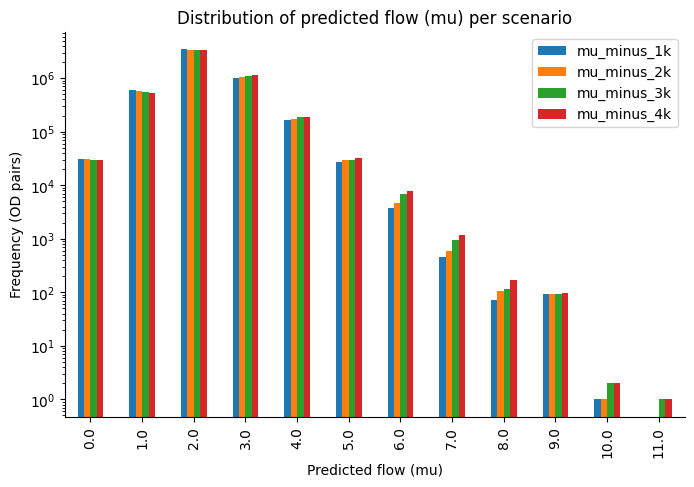

In [81]:
# PROCESSING
jn_3k = pd.concat(
    [
        np.floor(paths['mu_minus_1k_net_cost']).value_counts().sort_index(),
        np.floor(paths['mu_minus_2k_net_cost']).value_counts().sort_index(),
        np.floor(paths['mu_minus_3k_net_cost']).value_counts().sort_index(),
        np.floor(paths['mu_minus_4k_net_cost']).value_counts().sort_index()
    ],
    axis=1
)
jn_3k.columns = ['mu_minus_1k','mu_minus_2k','mu_minus_3k','mu_minus_4k']

# PLOTTING
fig, ax = plt.subplots(figsize=(8,5))

ax.set_xticks(np.arange(0, 13, 1))
ax.set_xticklabels(labels=[f"{n:,.0f}" for n in np.arange(0, 13, 1)])

jn_3k.plot(
    ax=ax,
    kind='bar'
)

ax.set_title('Distribution of predicted flow (mu) per scenario')
ax.set_xlabel("Predicted flow (mu)")
ax.set_ylabel("Frequency (OD pairs)")
ax.spines[['top','right']].set_visible(False)

plt.yscale('log')
plt.show()
plt.close()

## 4.2. Experiment

In [173]:
# Create global candidate non-beneficiary pool tracker from ORIGIN
ess_col = ['school_id_origin','count_non_beneficiary']
tracker_candidate_pool = student_flow[ess_col].groupby(['school_id_origin'], as_index=False)['count_non_beneficiary'].sum()

# Remove pairs with 0 count_non_beneficiary
mask = tracker_candidate_pool['count_non_beneficiary'].isna()
tracker_candidate_pool = tracker_candidate_pool.loc[~mask]
print(len(tracker_candidate_pool))
print(f"Count of candidate non-beneficiaries: {tracker_candidate_pool['count_non_beneficiary'].sum():,.0f}")

47179
Count of candidate non-beneficiaries: 1,579,844


In [174]:
# Create global ESC available slots tracker for DESTINATION
ess_cols = ['destination_school_id','available_slots']
tracker_esc_slots = esc_available[ess_cols]

# Filter out schools with 0 available slots
mask = tracker_esc_slots['available_slots'] != 0
tracker_esc_slots = tracker_esc_slots[mask]
print(len(tracker_esc_slots))
print(f"Count of available ESC slots: {tracker_esc_slots['available_slots'].sum():,.0f}")

1093
Count of available ESC slots: 26,608


In [162]:
# print(paths.shape)
# display(paths.head(1))

In [178]:
print(paths['origin_school_id'].nunique()), print(paths['destination_school_id'].nunique())

7622
1373


(None, None)

In [175]:
# Make dictionary tracker
TRACKER_CAND_POOL = tracker_candidate_pool.set_index('school_id_origin').to_dict()['count_non_beneficiary']

# Make dictionary tracker
TRACKER_ESC_SLOTS = tracker_esc_slots.set_index('destination_school_id').to_dict()['available_slots']

# Set one seed for shuffle
sd = 99

# For one scenario (i.e., mu_minus_1k_net_cost)
col_scenario = "mu_minus_1k_net_cost"

ess_cols = ['origin_school_id','destination_school_id',col_scenario]
paths_shuffle = paths[ess_cols].copy()

# Floor the mu values of the scenario
paths_shuffle['mu_floor'] =  np.floor(paths_shuffle[col_scenario])

# Shuffle order
paths_shuffle = paths_shuffle.sample(frac=1, random_state=sd).to_numpy()

In [171]:
itr = 0
for arr in tqdm(paths_shuffle):
    # display(arr)
    og_id = arr[0]
    dest_id = arr[1]
    mu_flr = arr[3]

    # display(TRACKER_CAND_POOL.get(og_id))
    # display(TRACKER_ESC_SLOTS.get(dest_id))

    # Stop if either resource is completely depleted
    if not any(TRACKER_CAND_POOL.values()) or not any(TRACKER_ESC_SLOTS.values()):
        print("Resource depletion detected. Terminating.")
        print(f"Terminated at i {itr}")
        break
    
    current_pool = TRACKER_CAND_POOL.get(og_id, 0)
    current_slots = TRACKER_ESC_SLOTS.get(dest_id, 0)
    
    # Checker: do we still have candidates from the origin school?
    if current_pool > 0:
        # Use min() to ensure we never subtract more than we have
        amount_to_subtract = min(current_pool, mu_flr)
        TRACKER_CAND_POOL[og_id] -= amount_to_subtract
        

    # Checker: do we still have ESC slots in the destination school?
    if current_slots > 0:
        # Use min() to ensure we never subtract more than we have
        amount_to_subtract = min(current_slots, mu_flr)
        TRACKER_ESC_SLOTS[dest_id] -= amount_to_subtract
    
    # display(TRACKER_CAND_POOL.get(og_id))
    # display(TRACKER_ESC_SLOTS.get(dest_id))
    itr += 1
    # break

100%|██████████| 5283589/5283589 [00:06<00:00, 851652.87it/s] 


In [154]:
# seed 143
sum(TRACKER_CAND_POOL.values())
sum(TRACKER_ESC_SLOTS.values())

234.0

In [169]:
# seed 1
sum(TRACKER_CAND_POOL.values())
sum(TRACKER_ESC_SLOTS.values())

234.0

In [172]:
# seed 99
sum(TRACKER_CAND_POOL.values())
sum(TRACKER_ESC_SLOTS.values())

234.0

---
# 5. Compute Decongestion Contributions

For each path, compute:
- `decongestion_X = mu_X × proportional_weight`
- `marginal_decong_X = (mu_X - mu_current) × proportional_weight`

In [21]:
# Display column names that have mu values
mu_cols = [col for col in cbp.columns if re.search(r'mu_minus', col)]
print(mu_cols)

['mu_minus_1k_net_cost', 'mu_minus_2k_net_cost', 'mu_minus_3k_net_cost', 'mu_minus_4k_net_cost', 'mu_minus_5k_net_cost', 'mu_minus_6k_net_cost', 'mu_minus_7k_net_cost', 'mu_minus_8k_net_cost', 'mu_minus_9k_net_cost', 'mu_minus_10k_net_cost', 'mu_minus_11k_net_cost', 'mu_minus_12k_net_cost', 'mu_minus_13k_net_cost', 'mu_minus_14k_net_cost', 'mu_minus_15k_net_cost', 'mu_minus_16k_net_cost', 'mu_minus_17k_net_cost', 'mu_minus_18k_net_cost', 'mu_minus_19k_net_cost', 'mu_minus_20k_net_cost']


In [22]:
# # Define scenarios
# SCENARIOS = {
#     'baseline': 'mu_baseline_0_subsidy',
#     'current': 'mu_with_current_subsidy',
#     'minus_1k': 'mu_with_minus_1k_net_cost',
#     'minus_10k': 'mu_with_minus_10k_net_cost',
#     'minus_15k': 'mu_with_minus_15k_net_cost',
#     'minus_20k': 'mu_with_minus_20k_net_cost',
# }
keys = ['baseline', 'current'] + ['minus_'+str(n)+'k' for n in range(1, 21)]
values = ['mu_baseline_0_subsidy', 'mu_current_subsidy'] + [col for col in mu_cols]
SCENARIOS = {k:v for k,v in zip(keys, values)}

print("Scenarios:")
for name, col in SCENARIOS.items():
    print(f"  {name}: {col}")

Scenarios:
  baseline: mu_baseline_0_subsidy
  current: mu_current_subsidy
  minus_1k: mu_minus_1k_net_cost
  minus_2k: mu_minus_2k_net_cost
  minus_3k: mu_minus_3k_net_cost
  minus_4k: mu_minus_4k_net_cost
  minus_5k: mu_minus_5k_net_cost
  minus_6k: mu_minus_6k_net_cost
  minus_7k: mu_minus_7k_net_cost
  minus_8k: mu_minus_8k_net_cost
  minus_9k: mu_minus_9k_net_cost
  minus_10k: mu_minus_10k_net_cost
  minus_11k: mu_minus_11k_net_cost
  minus_12k: mu_minus_12k_net_cost
  minus_13k: mu_minus_13k_net_cost
  minus_14k: mu_minus_14k_net_cost
  minus_15k: mu_minus_15k_net_cost
  minus_16k: mu_minus_16k_net_cost
  minus_17k: mu_minus_17k_net_cost
  minus_18k: mu_minus_18k_net_cost
  minus_19k: mu_minus_19k_net_cost
  minus_20k: mu_minus_20k_net_cost


In [23]:
# Compute decongestion contribution for each scenario
for name, mu_col in SCENARIOS.items():
    # Decongestion = mu × weight
    paths[f'decong_{name}'] = paths[mu_col] * paths['proportional_weight']

print("Decongestion columns created.")

Decongestion columns created.


In [24]:
# Compute marginal decongestion (vs current subsidy)
baseline_col = SCENARIOS['current']

for name, mu_col in SCENARIOS.items():
    if name == 'current':
        continue
    # Marginal = (mu_scenario - mu_current) × weight
    paths[f'marginal_{name}'] = (paths[mu_col] - paths[baseline_col]) * paths['proportional_weight']

print("Marginal decongestion columns created.")

Marginal decongestion columns created.


In [25]:
# Inspect sample results
result_cols = [
    'origin_school_id', 'destination_school_id', 'congested_school_id',
    'is_hypothetical', 'proportional_weight',
    'decong_current', 'decong_minus_1k', 'marginal_minus_2k',
    'decong_minus_3k', 'marginal_minus_4k', 'decong_minus_5k',
]

display(paths[result_cols].head(10))

,origin_school_id,destination_school_id,congested_school_id,is_hypothetical,proportional_weight,decong_current,decong_minus_1k,marginal_minus_2k,decong_minus_3k,marginal_minus_4k,decong_minus_5k
0,104408,401116,NaN,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,104412,401116,300693,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,104412,401116,320001,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,104457,401070,300787,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,104457,401070,300800,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,104457,401070,300828,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,104457,401070,301047,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,104457,401070,305382,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,104459,401365,500751,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,104460,402529,300765,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
# 6. Summary Statistics

In [34]:
# Total decongestion by path type (existing vs hypothetical)
summary = paths.groupby('is_hypothetical').agg({
    'decong_current': 'sum',
    'decong_minus_1k': 'sum',
    'decong_minus_2k': 'sum',
    'decong_minus_3k': 'sum',
    'decong_minus_4k': 'sum',
    'decong_minus_5k': 'sum',
}).round(1)

summary.index = summary.index.map({True: 'Hypothetical', False: 'Existing'})

print("=== Total Decongestion by Path Type ===")
display(summary.style.format("{:,.0f}"))

=== Total Decongestion by Path Type ===


,decong_current,decong_minus_1k,decong_minus_2k,decong_minus_3k,decong_minus_4k,decong_minus_5k
is_hypothetical,,,,,,
Existing,"252,483","254,440","256,572","258,916","261,260","263,705"
Hypothetical,"601,802","605,362","609,319","613,463","617,644","622,160"


In [25]:
# Marginal contribution by path type
marginal_summary = paths.groupby('is_hypothetical').agg({
    'marginal_minus_1k': 'sum',
    'marginal_minus_10k': 'sum',
    'marginal_minus_15k': 'sum',
    'marginal_minus_20k': 'sum',
}).round(1)

marginal_summary.index = marginal_summary.index.map({True: 'Hypothetical', False: 'Existing'})

print("=== Marginal Decongestion (vs Current Subsidy) ===")
display(marginal_summary.style.format("{:,.0f}"))

=== Marginal Decongestion (vs Current Subsidy) ===


,marginal_minus_1k,marginal_minus_10k,marginal_minus_15k,marginal_minus_20k
is_hypothetical,,,,
Existing,"1,175","15,659","24,067","31,104"
Hypothetical,"1,211","18,651","33,623","46,035"


In [21]:
# Percentage from hypothetical paths
total_decong = paths.groupby('is_hypothetical')['decong_minus_10k'].sum()
pct_hypothetical = total_decong[True] / total_decong.sum() * 100

print(f"\nHypothetical paths contribute {pct_hypothetical:.1f}% of total decongestion (at -10k scenario)")


Hypothetical paths contribute 61.3% of total decongestion (at -10k scenario)


---
# 7. Aggregation by Congested School

In [23]:
# Decongestion by congested school
by_congested = paths.groupby('congested_school_id').agg({
    'decong_current': 'sum',
    'decong_minus_1k': 'sum',
    'marginal_minus_1k': 'sum',
}).round(1)

by_congested = by_congested.sort_values('decong_minus_1k', ascending=False)

print("=== Top 15 Congested Schools by Decongestion (at -1k) ===")
display(by_congested.head(15))

=== Top 15 Congested Schools by Decongestion (at -1k) ===


,decong_current,decong_minus_1k,marginal_minus_1k
congested_school_id,,,
301190,2315.1,2332.8,17.6
301196,2195.1,2215.7,20.6
305330,2063.4,2086.8,23.5
301192,1961.8,1989.2,27.4
301186,1883.0,1920.7,37.7
301180,1765.0,1790.2,25.3
301171,1524.6,1531.9,7.3
301516,1151.8,1169.5,17.7
305413,1160.3,1168.3,8.1


In [27]:
# Breakdown by congested school AND path type
by_congested_type = paths.groupby(['congested_school_id', 'is_hypothetical']).agg({
    'decong_minus_1k': 'sum',
}).round(1).unstack(fill_value=0)

by_congested_type.columns = ['Existing', 'Hypothetical']
by_congested_type['Total'] = by_congested_type['Existing'] + by_congested_type['Hypothetical']
by_congested_type['Pct_Hypothetical'] = (by_congested_type['Hypothetical'] / by_congested_type['Total'] * 100).round(1)

by_congested_type = by_congested_type.sort_values('Total', ascending=False)

print("=== Decongestion by Congested School (minus 1k): Existing vs Hypothetical ===")
display(by_congested_type.head(15))

=== Decongestion by Congested School (minus 1k): Existing vs Hypothetical ===


,Existing,Hypothetical,Total,Pct_Hypothetical
congested_school_id,,,,
301190,684.2,1648.5,2332.7,70.7
301196,676.6,1539.1,2215.7,69.5
305330,213.1,1873.8,2086.9,89.8
301192,857.9,1131.3,1989.2,56.9
301186,221.7,1699.0,1920.7,88.5
301180,724.1,1066.1,1790.2,59.6
301171,460.0,1071.9,1531.9,70.0
301516,379.8,789.7,1169.5,67.5
305413,356.0,812.4,1168.4,69.5


---
# 8. Export Results

In [ ]:
# Create export directory
EXPORT_DIR = OUTPUT_DIR / "path_marginal_analysis"
EXPORT_DIR.mkdir(exist_ok=True)

# Export path-level results
paths.to_parquet(EXPORT_DIR / "path_level_results.parquet", index=False)
print(f"✓ Exported path_level_results.parquet ({paths.shape[0]:,} rows)")

# Export summary by congested school
by_congested_type.to_csv(EXPORT_DIR / "decongestion_by_congested_school.csv")
print(f"✓ Exported decongestion_by_congested_school.csv")

print(f"\nAll exports saved to: {EXPORT_DIR}")